In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [19]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

In [20]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 2)
        self.fc_logvar = nn.Linear(400, 2)

        self.fc3 = nn.Linear(2, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [21]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [22]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [24]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 25

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_function(recon, data, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

Epoch 1, Avg Loss: 191.2316
Epoch 2, Avg Loss: 168.1006
Epoch 3, Avg Loss: 163.0220
Epoch 4, Avg Loss: 160.4053
Epoch 5, Avg Loss: 158.6631
Epoch 6, Avg Loss: 157.4474
Epoch 7, Avg Loss: 156.4029
Epoch 8, Avg Loss: 155.5202
Epoch 9, Avg Loss: 154.8187
Epoch 10, Avg Loss: 154.2216
Epoch 11, Avg Loss: 153.6068
Epoch 12, Avg Loss: 153.1072
Epoch 13, Avg Loss: 152.6330
Epoch 14, Avg Loss: 152.2388
Epoch 15, Avg Loss: 151.8768
Epoch 16, Avg Loss: 151.4835
Epoch 17, Avg Loss: 151.1534
Epoch 18, Avg Loss: 150.8624
Epoch 19, Avg Loss: 150.5619
Epoch 20, Avg Loss: 150.2459
Epoch 21, Avg Loss: 149.9522
Epoch 22, Avg Loss: 149.7062
Epoch 23, Avg Loss: 149.4665
Epoch 24, Avg Loss: 149.2513
Epoch 25, Avg Loss: 149.0064


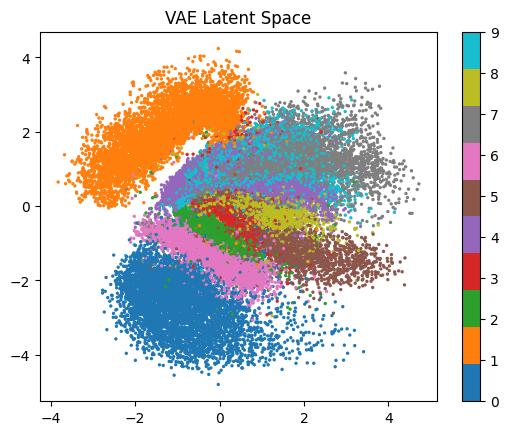

In [25]:
model.eval()
zs = []
labels = []

with torch.no_grad():
    for data, y in train_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        zs.append(mu.cpu())
        labels.append(y)

zs = torch.cat(zs)
labels = torch.cat(labels)

plt.scatter(zs[:,0], zs[:,1], c=labels, cmap='tab10', s=2)
plt.colorbar()
plt.title("VAE Latent Space")
plt.show()

In [26]:
transform_gan = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform_gan)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

In [27]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [28]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

epochs = 20

for epoch in range(epochs):
    for real, _ in train_loader:

        real = real.view(-1, 784).to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        loss_real = criterion(D(real), real_labels)
        loss_fake = criterion(D(fake.detach()), fake_labels)
        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        z = torch.randn(batch_size, 100).to(device)
        fake = G(z)

        loss_G = criterion(D(fake), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")

Epoch 1 | D: 0.0347 | G: 5.4332
Epoch 2 | D: 0.2540 | G: 4.5708
Epoch 3 | D: 0.5129 | G: 3.8613
Epoch 4 | D: 0.4948 | G: 2.3330
Epoch 5 | D: 0.1404 | G: 3.2276
Epoch 6 | D: 0.1308 | G: 4.1838
Epoch 7 | D: 0.3248 | G: 6.0361
Epoch 8 | D: 0.1033 | G: 5.6912
Epoch 9 | D: 0.1861 | G: 3.3421
Epoch 10 | D: 0.3670 | G: 6.7158
Epoch 11 | D: 0.0829 | G: 6.7998
Epoch 12 | D: 0.2411 | G: 4.6534
Epoch 13 | D: 0.1933 | G: 5.0937
Epoch 14 | D: 0.2502 | G: 5.0112
Epoch 15 | D: 0.2260 | G: 3.4319
Epoch 16 | D: 0.2631 | G: 3.3499
Epoch 17 | D: 0.3949 | G: 2.5809
Epoch 18 | D: 0.5087 | G: 2.6613
Epoch 19 | D: 0.2647 | G: 4.9068
Epoch 20 | D: 0.1245 | G: 5.0917


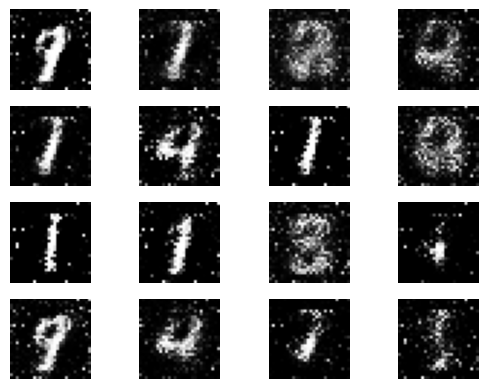

In [29]:
z = torch.randn(16, 100).to(device)
generated = G(z).view(-1, 28, 28).detach().cpu()

fig, axes = plt.subplots(4, 4)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(generated[i], cmap='gray')
    ax.axis('off')

plt.show()

In [30]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.8 MB/s eta 0:00:0000:0100:01


In [31]:
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

dataset = Planetoid(root='data/Cora', name='Cora')
data = dataset[0].to(device)

Processing...
Done!


In [65]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.dropout(x, p=0.5, train=self.training)  # IMPORTANT

        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [68]:
model = GCN().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,              # lower LR
    weight_decay=5e-4      # VERY IMPORTANT
)

for epoch in range(300):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.9543
Epoch 20, Loss: 0.7289
Epoch 40, Loss: 0.2152
Epoch 60, Loss: 0.1069
Epoch 80, Loss: 0.0584
Epoch 100, Loss: 0.0603
Epoch 120, Loss: 0.0380
Epoch 140, Loss: 0.0574
Epoch 160, Loss: 0.0375
Epoch 180, Loss: 0.0426
Epoch 200, Loss: 0.0538
Epoch 220, Loss: 0.0388
Epoch 240, Loss: 0.0410
Epoch 260, Loss: 0.0307
Epoch 280, Loss: 0.0268


In [69]:
model.eval()
pred = model(data).argmax(dim=1)

correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())

print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.8000
